<a href="https://colab.research.google.com/github/Ezzgiturann/Softito_Homework/blob/main/21_09_26_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.12.3
Platform:Linux-6.18.44-fc-v37-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 3.0.2
numpy: 2.4.4
sklearn: 1.8.0


In [ ]:
# CSV dosyasını Colab'da soldaki 📁 panele yükle
wec = pd.read_csv("WEC_Perth_49.csv")
wec.head(2)

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,X6,Y6,X7,Y7,X8,Y8,X9,Y9,X10,Y10,X11,Y11,X12,Y12,X13,Y13,X14,Y14,X15,Y15,X16,Y16,X17,Y17,X18,Y18,X19,Y19,X20,Y20,...,Power12,Power13,Power14,Power15,Power16,Power17,Power18,Power19,Power20,Power21,Power22,Power23,Power24,Power25,Power26,Power27,Power28,Power29,Power30,Power31,Power32,Power33,Power34,Power35,Power36,Power37,Power38,Power39,Power40,Power41,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0,0.0,546.16,37.5,489.79,74.88,432.47,112.05,650.0,0.0,700.0,0.0,750.0,0.0,800.0,0.0,850.0,0.0,900.0,0.0,950.0,0.0,1000.0,0.0,1000.0,200.0,946.16,237.5,889.79,274.88,832.47,312.05,200.0,400.0,146.16,437.5,89.79,474.88,0.0,612.05,...,96695.12,99775.05,101719.17,101433.80,98288.19,59176.83,61966.02,61420.10,59012.29,62564.84,68951.29,77342.19,77549.65,75571.59,78873.22,80234.92,76780.93,98803.86,101561.96,101687.45,99514.19,78247.60,72312.74,67823.86,70450.89,99251.34,101500.92,101599.89,99552.24,77097.57,88867.92,98844.30,101283.59,98934.63,101624.58,100915.03,99625.68,96704.34,0.87,4102461.43
1,593.0,12.0,546.16,37.5,489.79,74.88,432.47,112.05,644.0,8.0,700.0,0.0,750.0,0.0,800.0,0.0,850.0,0.0,900.0,0.0,950.0,0.0,1000.0,0.0,1000.0,200.0,946.16,237.5,889.79,274.88,832.47,312.05,200.0,400.0,146.16,437.5,89.79,474.88,0.0,612.05,...,97010.26,99426.19,101857.97,101586.31,98418.24,58221.09,61220.26,60838.46,59644.57,62558.91,68790.79,77115.89,77374.73,75567.28,78779.95,80338.00,76946.13,98836.68,101445.33,101676.91,99747.45,77165.22,71104.47,68621.43,70411.56,99234.99,101566.70,101557.24,99569.69,77044.77,88896.55,98759.79,101346.07,98873.59,101629.01,100934.53,99606.13,96718.39,0.87,4103361.41


In [ ]:
wec.info()

<class 'pandas.DataFrame'>
RangeIndex: 36043 entries, 0 to 36042
Columns: 149 entries, X1 to Total_Power
dtypes: float64(149)
memory usage: 41.0 MB


In [ ]:
# Veride çok sayıda birebir aynı satır var, onları siliyoruz
print("Tekrarlanan satır:", wec.duplicated().sum())
wec = wec.drop_duplicates().reset_index(drop=True)
print("Yeni boyut:", wec.shape)

Tekrarlanan satır: 25107
Yeni boyut: (10936, 149)


In [ ]:
# Power1..Power49 ve qW, Total_Power'dan türetildiği için kullanılmıyor (data leakage)
konum_sutunlari = [f"X{i}" for i in range(1, 50)] + [f"Y{i}" for i in range(1, 50)]

X_reg = wec[konum_sutunlari]
y_reg = wec["Total_Power"]

In [ ]:
y_reg

0        4102461.43
1        4103361.41
2        4103680.44
3        4105661.06
4        3752648.77
            ...    
10931    4048188.53
10932    4033017.16
10933    4048053.62
10934    4062515.64
10935    4057544.99
Name: Total_Power, Length: 10936, dtype: float64

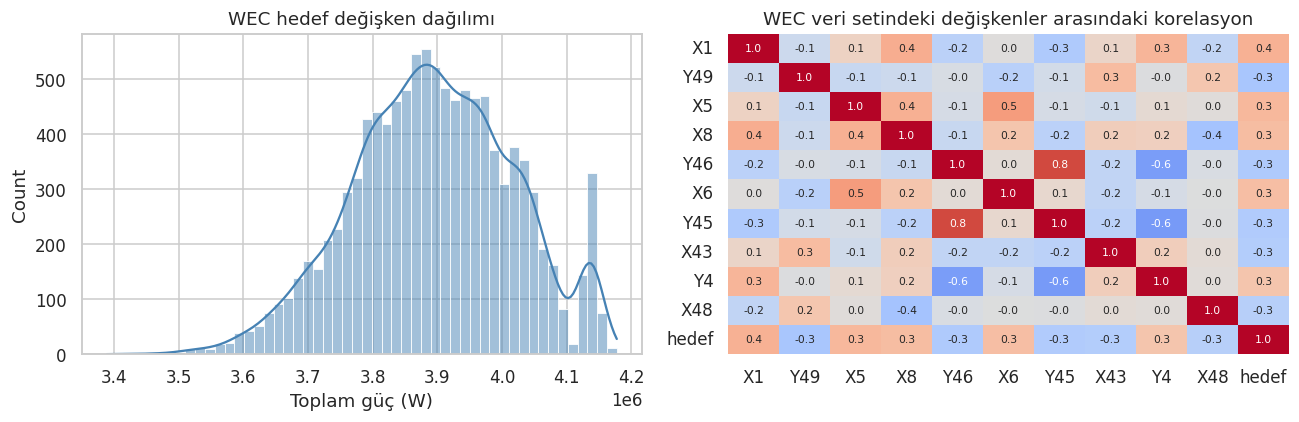

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(y_reg,kde=True,ax=axes[0],color="steelblue")
axes[0].set_title("WEC hedef değişken dağılımı")
axes[0].set_xlabel("Toplam güç (W)")

# 98 değişken sığmadığı için hedefle en ilişkili 10 değişken
en_iyi_10 = X_reg.corrwith(y_reg).abs().sort_values(ascending=False).head(10).index

corr =pd.concat([X_reg[en_iyi_10],y_reg.rename("hedef")],axis =1).corr()
sns.heatmap(corr,annot=True,fmt=".1f",cmap="coolwarm",center=0,
            ax=axes[1],cbar=False, annot_kws ={"size":7})
axes[1].set_title("WEC veri setindeki değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
Xr_train,Xr_test,yr_train,yr_test=train_test_split(X_reg,y_reg,test_size=0.2,random_state=SEED)

In [ ]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

8748


2188

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(Xr_train,yr_train)

linear = LinearRegression().fit(Xr_train,yr_train)

def regresyon_raporu (model,X, y,ad):
  tahmin=model.predict(X)
  return{
     "Model" :ad,
     "Mae"   : mean_absolute_error(y,tahmin),
     "mse"   : mean_squared_error(y,tahmin),
     "rmse"  : np.sqrt(mean_squared_error(y,tahmin)),
     "r2"    : r2_score(y,tahmin)
    }
sonuc = pd.DataFrame([
    regresyon_raporu(baseline,Xr_test,yr_test,"Baseline"),
    regresyon_raporu(linear,Xr_test,yr_test,"Linear")
]).set_index("Model").round(3)
sonuc

,Mae,mse,rmse,r2
Model,,,,
Baseline,101117.534,1.565848e+10,125133.832,-0.000
Linear,48422.415,3.973396e+09,63034.878,0.746


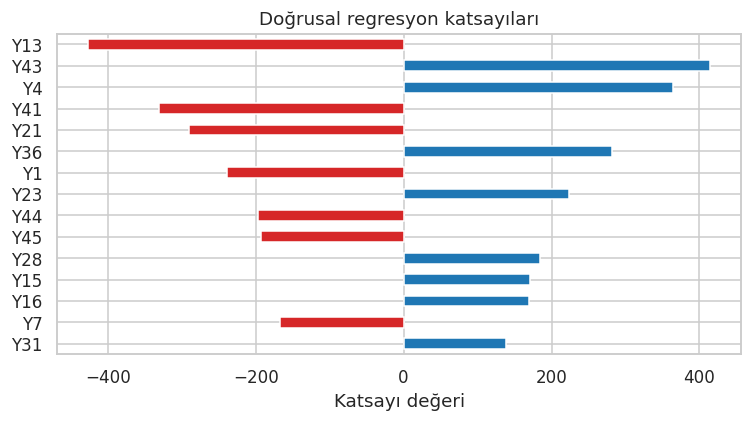

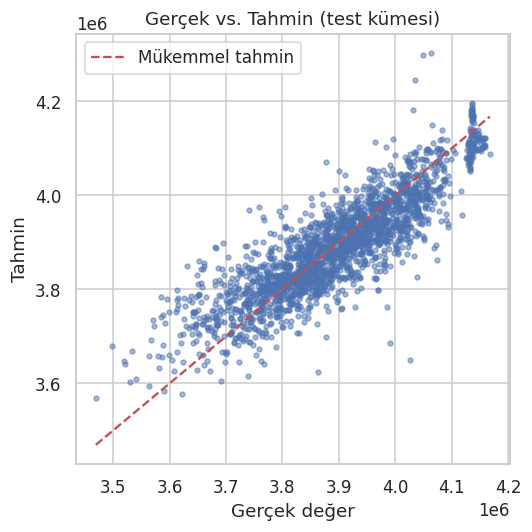

In [ ]:
# 98 katsayı sığmadığı için mutlak değerce en büyük 15 katsayı
katsayilar = pd.Series(linear.coef_, index=X_reg.columns)
katsayilar = katsayilar.reindex(katsayilar.abs().sort_values().index).tail(15)

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()


tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.5, s=10)
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Hedef milyonlar mertebesinde olduğu için Lasso'da alpha=1000 seçildi
modeller= {
    "Doğrusal": make_pipeline(StandardScaler(),LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(),Lasso(alpha=1000, max_iter=10000))
}

satirlar =[]

for ad,m in modeller.items():
  m.fit(Xr_train,yr_train)
  satirlar.append(regresyon_raporu(m,Xr_test,yr_test,ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,48422.415,3.973396e+09,63034.878,0.746
Ridge,48421.181,3.972847e+09,63030.524,0.746
Lasso,49691.156,4.134679e+09,64301.467,0.736


In [ ]:
lasso= modeller["Lasso"].named_steps["lasso"]
print("Lasso'nun sıfırladığı değişken sayısı:", (lasso.coef_ == 0).sum())
pd.Series(lasso.coef_,index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

Lasso'nun sıfırladığı değişken sayısı: 34


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,...,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,Y21,Y22,Y23,Y24,Y25,Y26,Y27,Y28,Y29,Y30,Y31,Y32,Y33,Y34,Y35,Y36,Y37,Y38,Y39,Y40,Y41,Y42,Y43,Y44,Y45,Y46,Y47,Y48,Y49
Lasso değişkenler,24230.6,8338.98,6.74,10978.03,13252.1,13201.61,8314.98,10837.09,9356.49,12089.72,11476.88,5513.96,7450.91,10331.28,0.0,-0.0,5893.5,4048.93,3994.37,0.0,0.0,-0.0,-0.0,-1481.11,0.0,0.0,2971.77,0.0,-0.0,-0.0,-3252.4,-6296.17,-0.0,-2292.9,-5479.19,-8563.33,-5087.93,-7229.3,-8057.75,-9463.23,...,-1084.23,-0.0,-0.0,-31969.91,-1117.66,5390.13,13289.2,-1903.01,-1194.57,-3587.37,-0.0,-20925.2,0.0,15576.89,0.0,-858.13,-0.0,0.0,8213.75,-0.0,-0.0,8653.88,-0.0,-0.0,-0.0,-0.0,16941.03,0.0,0.0,-0.0,3749.8,-18197.86,-0.0,15786.46,-1638.62,-19168.37,-5444.49,-1850.95,0.0,-13858.66


In [ ]:
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'Lasso'])
